# Hotel Booking Cancellation Prediction

Predicting hotel booking cancellations on **119,390 real reservation records** 
(Kaggle *Hotel Booking Demand* dataset) and identifying the factors that drive 
cancellation behavior.

**Goal:** help hotels reduce revenue loss by (1) understanding *why* guests cancel 
and (2) predicting *which* bookings are at risk.

**Approach:** data cleaning &rarr; exploratory analysis &rarr; a scikit-learn 
`Pipeline` with Random Forest / Decision Tree classifiers (leakage-prone fields 
deliberately excluded) &rarr; feature-importance interpretation.

**Headline result:** ~83% test accuracy; top cancellation drivers are 
**deposit type**, **lead time**, and **average daily rate (ADR)**.

---

*Author: Ruimin (Sylvia) Pei*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.options.display.max_columns = None

In [2]:
data = pd.read_csv('hotel_bookings.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Preprocessing

### Missing Value

In [4]:
data.isnull().sum().sort_values(ascending=False)[:10]

company                   112593
agent                      16340
country                      488
children                       4
reserved_room_type             0
assigned_room_type             0
booking_changes                0
deposit_type                   0
hotel                          0
previous_cancellations         0
dtype: int64

In [5]:
df = data.copy()

df = df.drop(df[(df.adults+df.babies+df.children)==0].index)
df[['agent','company']] = df[['agent','company']].fillna(0.0)
df['country'] = df['country'].fillna(data.country.mode().to_string())
df['children'] = df['children'].fillna(round(data.children.mean()))


### OutLiers

<Axes: xlabel='is_canceled', ylabel='adr'>

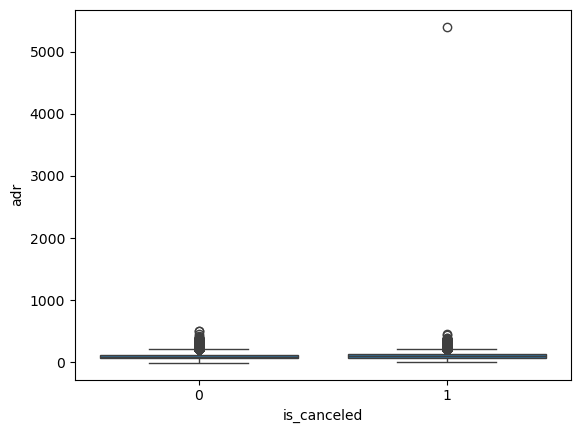

In [6]:
sns.boxplot(x="is_canceled", y="adr", data=df)

In [7]:
adr_deletmax=df[df["adr"]!=5400]

<Axes: xlabel='is_canceled', ylabel='adr'>

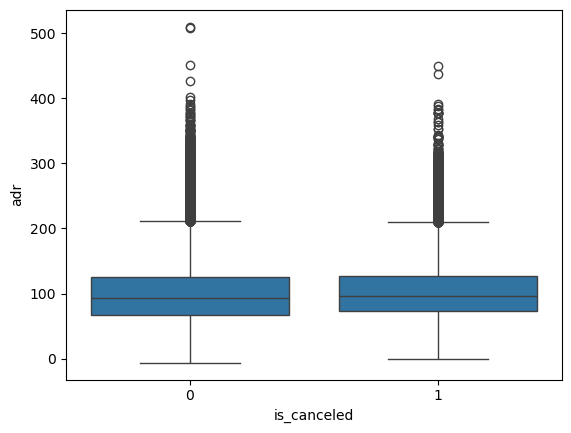

In [8]:
sns.boxplot(x="is_canceled", y="adr", data=adr_deletmax)

### Correlation

<Axes: >

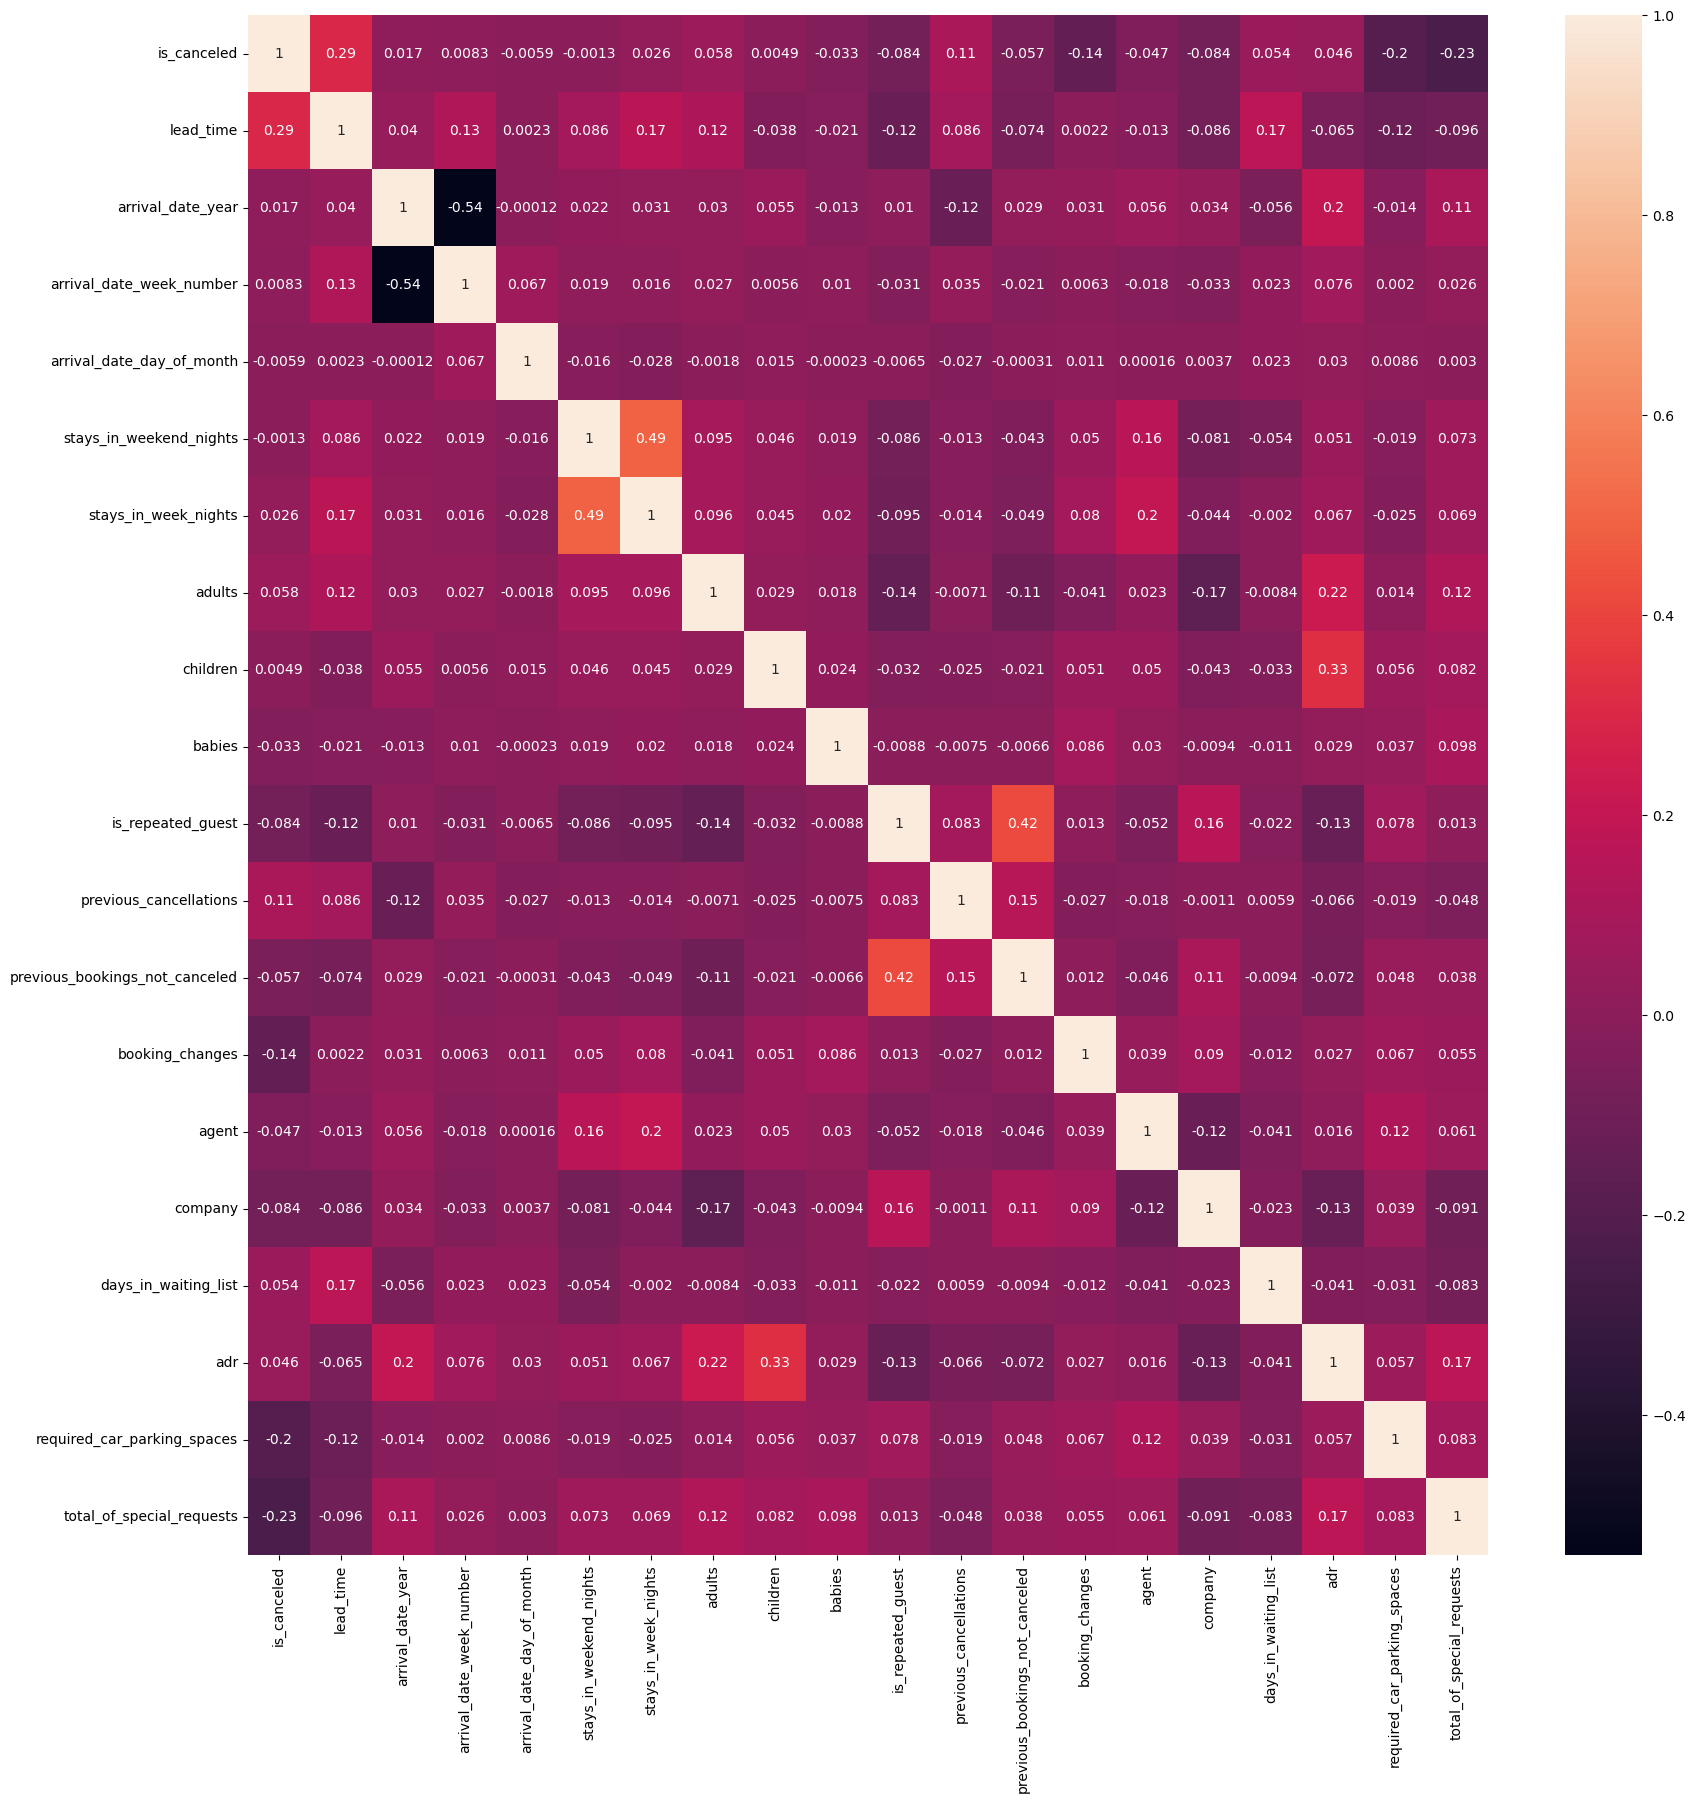

In [9]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Desctiptive Analysis

#### How many bookings and cancellations are there, and what patterns can be discerned?

<Figure size 1000x600 with 0 Axes>

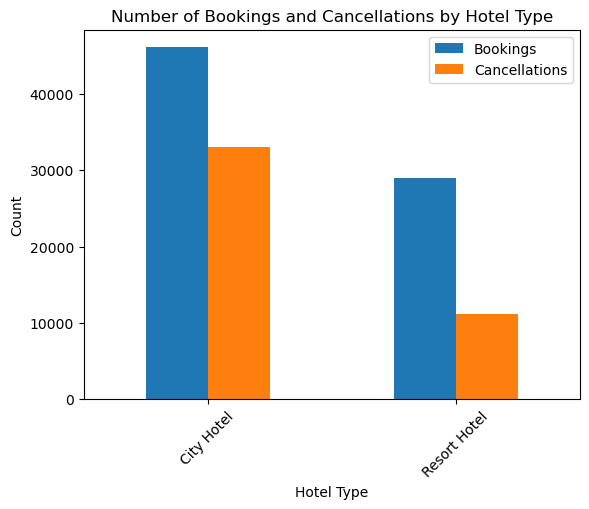

In [10]:
# Counting the number of bookings and cancellations for each hotel type
booking_counts = df.groupby('hotel')['is_canceled'].value_counts().unstack()

# Creating a bar plot
plt.figure(figsize=(10, 6))
ax = booking_counts.plot(kind='bar', stacked=False, rot=0)
ax.set_xticklabels(booking_counts.index, rotation=45)
plt.title('Number of Bookings and Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.legend(['Bookings', 'Cancellations'])
plt.show()

#### What is the distribution of hotel bookings across different months?

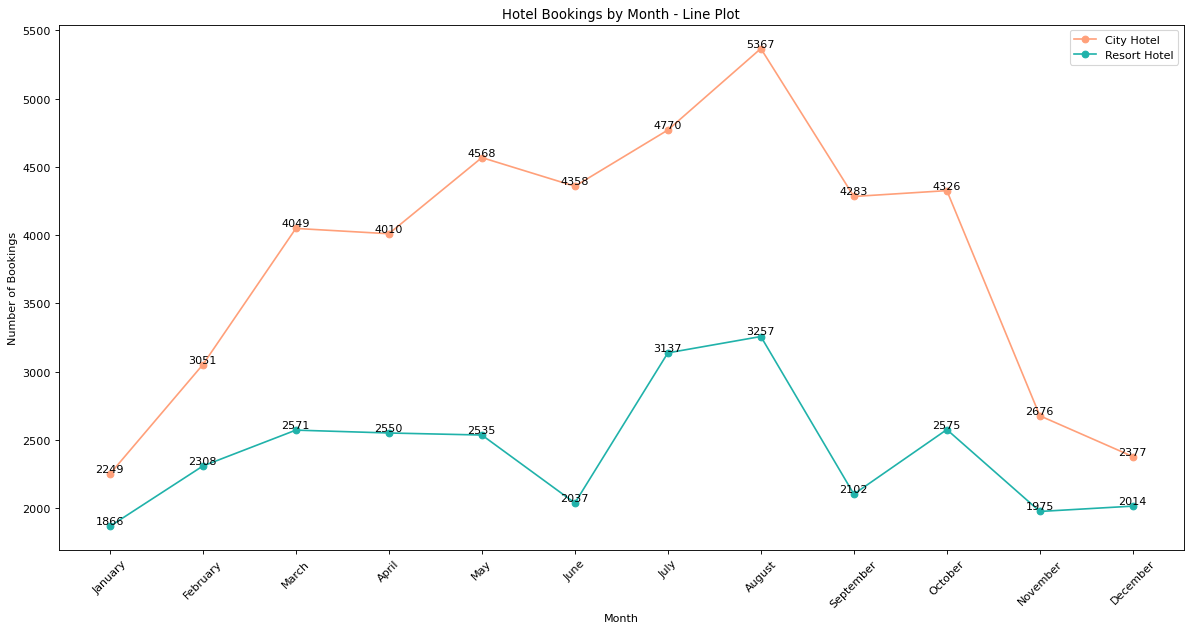

In [11]:

# Defining the months in calendar order
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Filtering out non-canceled bookings for each hotel type
city_hotel = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)].reset_index(drop=True)
resort_hotel = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)].reset_index(drop=True)

# Getting the monthly booking counts for each hotel type
city_month = city_hotel['arrival_date_month'].value_counts().reindex(months)
resort_month = resort_hotel['arrival_date_month'].value_counts().reindex(months)

# Plotting the line plot
plt.figure(figsize=(15,8), dpi=80)
plt.plot(months, city_month.values, marker='o', label='City Hotel', color='lightsalmon')
plt.plot(months, resort_month.values, marker='o', label='Resort Hotel', color='lightseagreen')
plt.xticks(rotation=45)
plt.legend()
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.title('Hotel Bookings by Month - Line Plot')

# Adding data labels
for x_val, y_val in zip(months, city_month.values):
    plt.text(x_val, y_val + 0.1, f'{int(y_val)}', ha='center', va='bottom')

for x_val, y_val in zip(months, resort_month.values):
    plt.text(x_val, y_val + 0.1, f'{int(y_val)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


#### What is the relationship between guests' countries of origin and their booking cancellation rates?

Text(0.5, 1.0, 'Main Source of Guests')

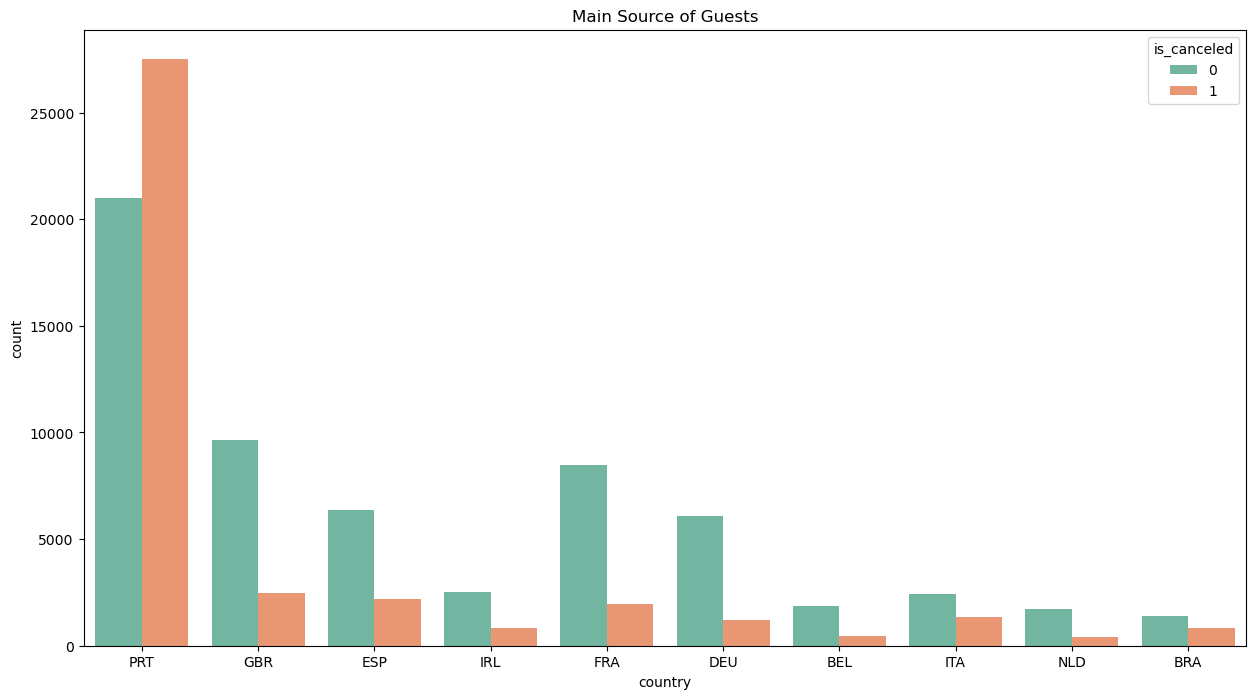

In [12]:
country_book=df['country'].value_counts()[:10]
country_cancel=df[(df.country.isin (country_book.index)) & (df.is_canceled==1)]['country'].value_counts()
plt.figure(figsize=(15,8))
sns.countplot(x='country'
              ,data=df[df.country.isin (country_book.index)]
              ,hue='is_canceled'
              ,palette=sns.color_palette('Set2',2)
             )
plt.title('Main Source of Guests')

#### What are the different customer segments based on their booking behaviors?

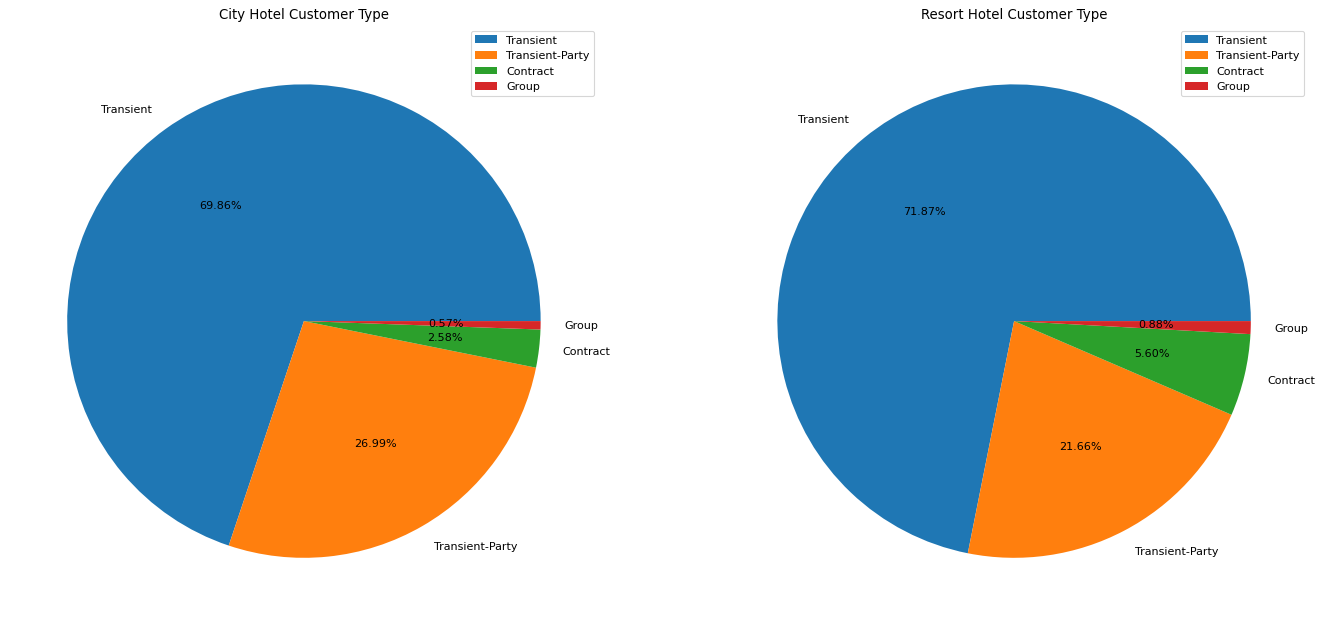

In [13]:
city_customer=city_hotel.customer_type.value_counts()
resort_customer=resort_hotel.customer_type.value_counts()
plt.figure(figsize=(21,12),dpi=80)
plt.subplot(1,2,1)
plt.pie(city_customer,labels=city_customer.index,autopct='%.2f%%')
plt.legend(loc=1)
plt.title('City Hotel Customer Type')
plt.subplot(1,2,2)
plt.pie(resort_customer,labels=resort_customer.index,autopct='%.2f%%')
plt.title('Resort Hotel Customer Type')
plt.legend()
plt.show()

#### Which channels are most used for hotel bookings?

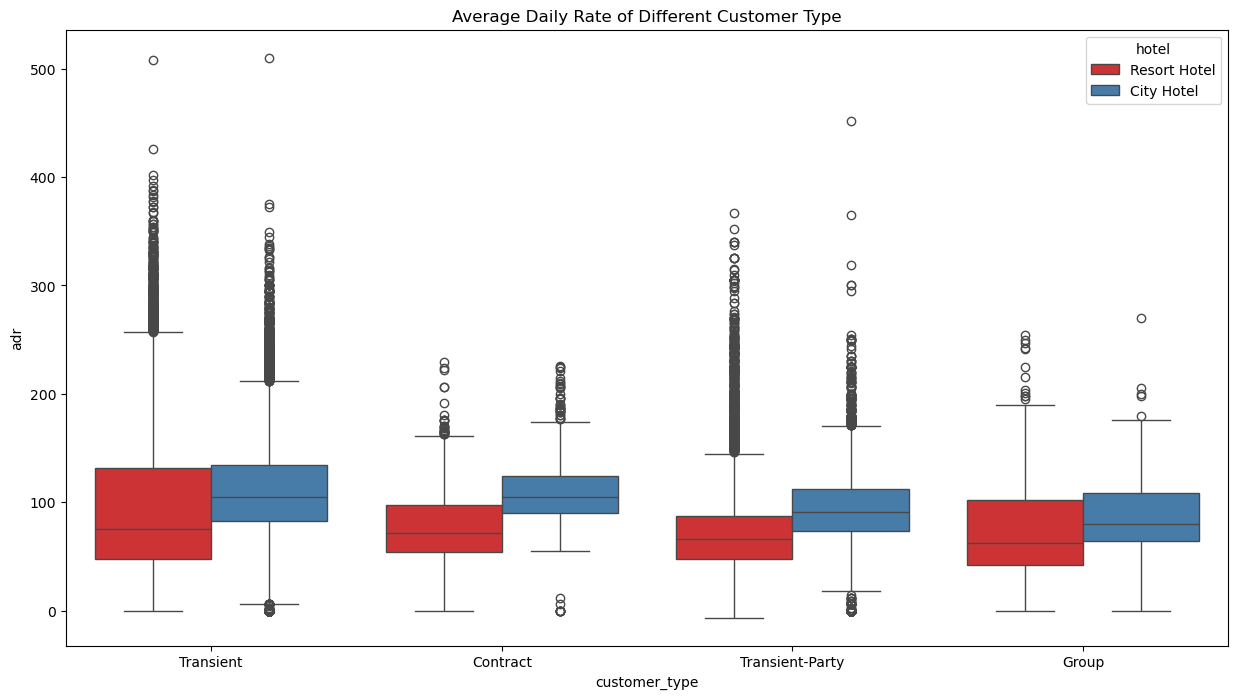

In [14]:
plt.figure(figsize=(15,8))
sns.boxplot(x='customer_type',
            y='adr',
            hue='hotel',
            data=df[df.is_canceled == 0],
            palette='Set1') 
plt.title('Average Daily Rate of Different Customer Type')
plt.show()

#### How do cancellation rates differ between new and returning guests?

([<matplotlib.axis.XTick at 0x16ac5a850>,
 [Text(0, 0, 'no'), Text(1, 0, 'yes')])

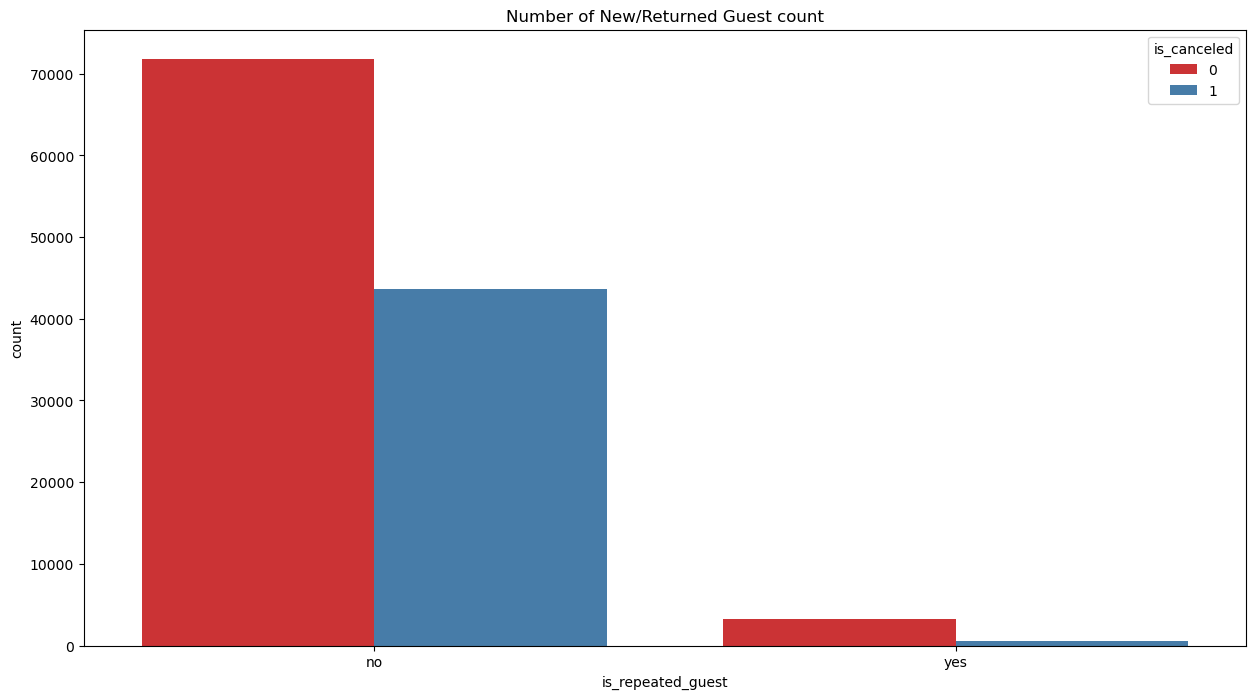

In [15]:
plt.figure(figsize=(15,8))
sns.countplot(x='is_repeated_guest'
              ,data=df
              ,hue='is_canceled'
              ,palette='Set1'
             )
plt.title('Number of New/Returned Guest count')
plt.xticks(range(2),['no','yes'])

### How do different deposit methods impact cancellation rates?

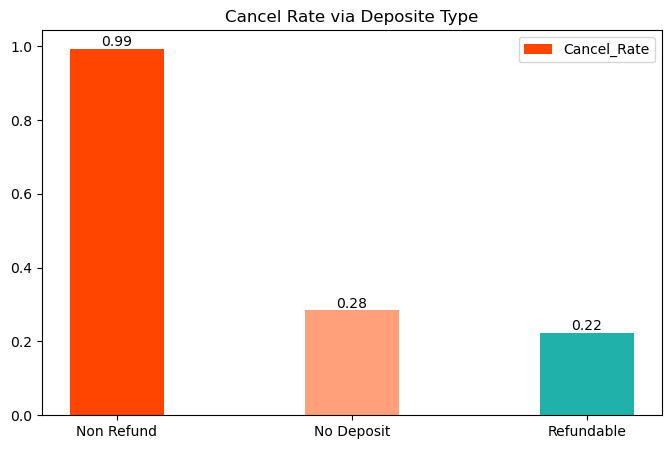

In [16]:
deposit_cancel=(df.loc[df['is_canceled']==1]['deposit_type'].value_counts()/df['deposit_type'].value_counts()).sort_values(ascending=False)
plt.figure(figsize=(8,5))
x=range(len(deposit_cancel.index))
y=deposit_cancel.values
plt.bar(x,y,label='Cancel_Rate',color=['orangered','lightsalmon','lightseagreen'],width=0.4)
plt.xticks(x,deposit_cancel.index)
plt.legend()
plt.title('Cancel Rate via Deposite Type')
for x,y in zip(x,y):
    plt.text(x,y,'%.2f' % y,ha = 'center',va = 'bottom')

### How do different deposit methods impact cancellation rates?

Text(0.5, 1.0, 'Book & Cancel Amount of Room Type')

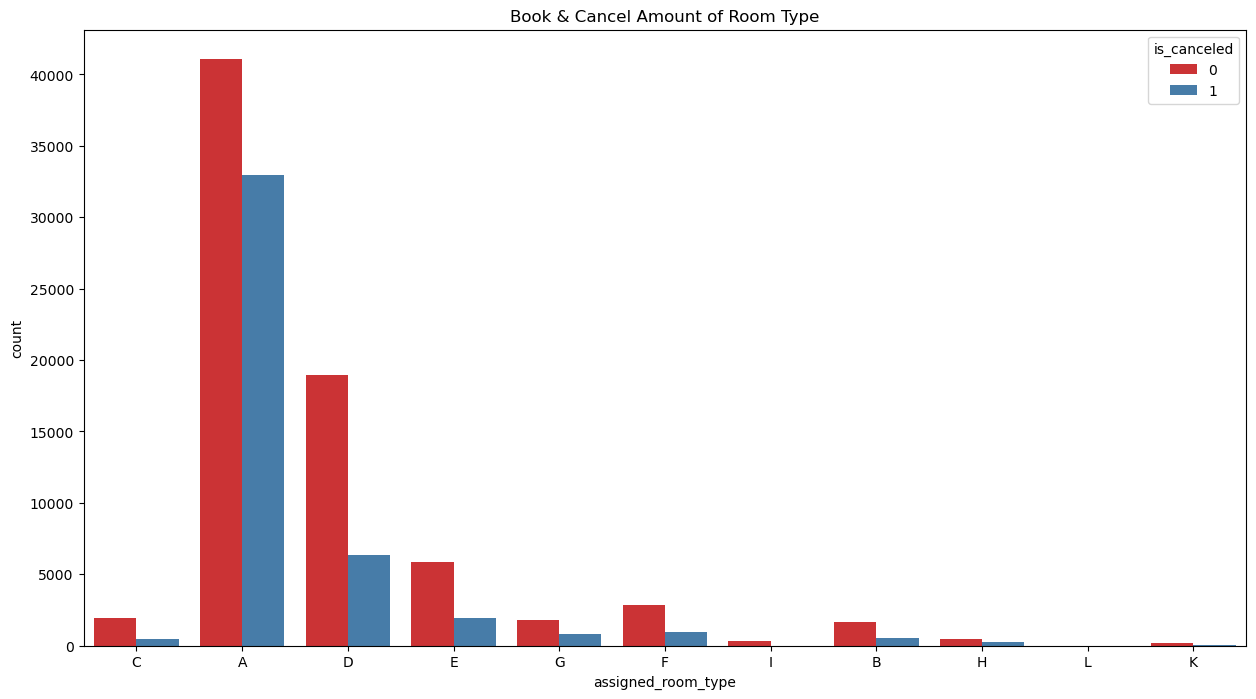

In [17]:
plt.figure(figsize=(15,8))
sns.countplot(x='assigned_room_type'
              ,data=df
              ,hue='is_canceled'
              ,palette='Set1'
             )
plt.title('Book & Cancel Amount of Room Type')

## Feature Engineering

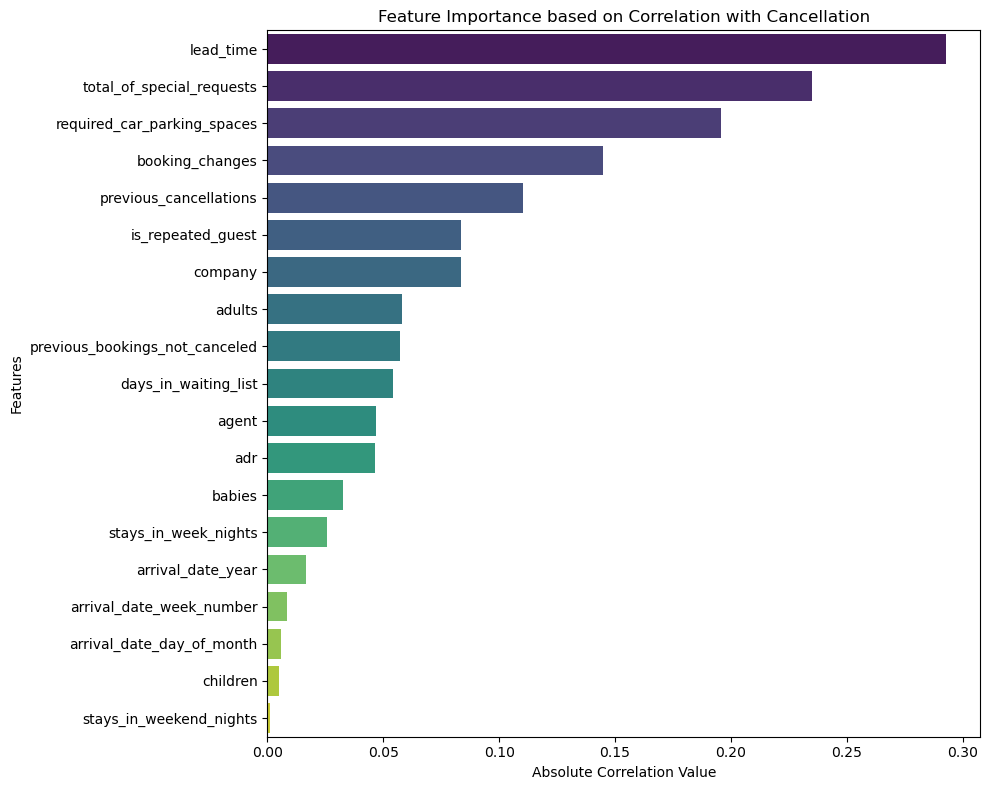

In [18]:
#Which numerical features are most important?
cancel_corr = df.corr(numeric_only=True)["is_canceled"].abs().sort_values(ascending=False)[1:]

# Create a bar plot for the correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=cancel_corr.values, y=cancel_corr.index, hue=cancel_corr.index, palette="viridis", legend=False)
plt.title('Feature Importance based on Correlation with Cancellation')
plt.xlabel('Absolute Correlation Value')
plt.ylabel('Features')

# Show the plot
plt.tight_layout()
plt.show()


In [19]:
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [20]:
# Select columns to include, excluding some to make the model more general and to prevent leakage
# (arrival_date_year, assigned_room_type, booking_changes, reservation_status, country, days_in_waiting_list)

num_features = ["lead_time", "arrival_date_week_number", "arrival_date_day_of_month",
                "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children",
                "babies", "is_repeated_guest", "previous_cancellations",
                "previous_bookings_not_canceled", "agent", "company",
                "required_car_parking_spaces", "total_of_special_requests", "adr"]

cat_features = ["hotel", "arrival_date_month", "meal", "market_segment",
                "distribution_channel", "reserved_room_type", "deposit_type", "customer_type"]

# Separate features and target value
features = num_features + cat_features
X = df.drop(["is_canceled"], axis=1)[features]
y = df["is_canceled"]

# Preprocess numerical features: fill missing values with 0
num_transformer = SimpleImputer(strategy="constant")

# Preprocess categorical features: fill missing values with "Unknown" and apply one-hot encoding
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))])

# Bundle preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(transformers=[("num", num_transformer, num_features),
                                               ("cat", cat_transformer, cat_features)])

In [21]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Create a pipeline that includes preprocessing and model fitting
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', rf_model)])

# Fit the model using the training data
pipeline.fit(X_train, y_train)

# Make predictions using the testing data
y_pred = pipeline.predict(X_test)

# Print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     14958
           1       0.87      0.76      0.81      8884

    accuracy                           0.87     23842
   macro avg       0.87      0.85      0.86     23842
weighted avg       0.87      0.87      0.87     23842



In [22]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Create a pipeline that includes preprocessing and model fitting
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', dt_model)])

# Fit the model using the training data
pipeline.fit(X_train, y_train)

# Make predictions using the testing data
y_pred = pipeline.predict(X_test)

# Print the classification report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.86      0.86      0.86     14958
           1       0.77      0.77      0.77      8884

    accuracy                           0.83     23842
   macro avg       0.82      0.82      0.82     23842
weighted avg       0.83      0.83      0.83     23842



In [23]:
from sklearn.tree import DecisionTreeClassifier

# Preprocess the data
X_preprocessed = preprocessor.fit_transform(X)

# Train the decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_preprocessed, y)

# Get one-hot encoded feature names (new sklearn uses get_feature_names_out)
onehot_columns = list(preprocessor.named_transformers_['cat'].
                      named_steps['onehot'].
                      get_feature_names_out(cat_features))

# Combine numerical features and one-hot encoded categorical features
feat_imp_list = num_features + onehot_columns

# Show the 10 most important features with their names (sklearn built-in)
feat_imp_df = pd.DataFrame({
    'feature': feat_imp_list,
    'weight': dt_model.feature_importances_
}).sort_values('weight', ascending=False).reset_index(drop=True)

feat_imp_df.head(10)

,feature,weight
0,deposit_type_Non Refund,0.238431
1,lead_time,0.151151
2,adr,0.099098
3,arrival_date_day_of_month,0.070530
4,total_of_special_requests,0.055787
5,arrival_date_week_number,0.052612
6,agent,0.046633
7,market_segment_Online TA,0.039354
8,stays_in_week_nights,0.039295
9,previous_cancellations,0.032803


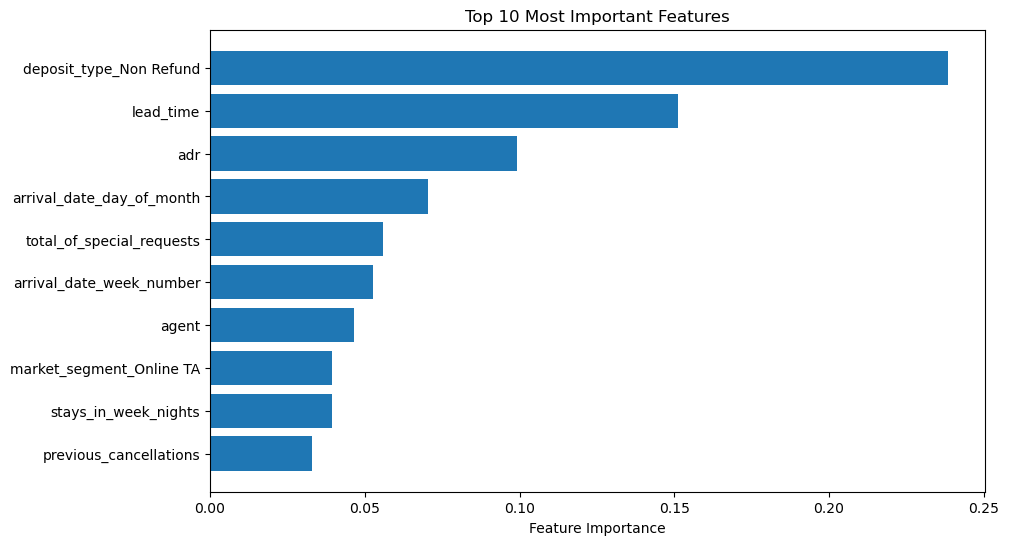

In [24]:
import matplotlib.pyplot as plt

# Get the top 10 most important features
top_feat_imp_df = feat_imp_df.head(10)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feat_imp_df['feature'], top_feat_imp_df['weight'], align='center')
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert the y-axis to show the most important feature at the top
plt.show()
